In [ ]:
import requests
import pandas as pd

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 22.5726,
    "longitude": 88.3639,
    "start_date": "2015-01-01",
    "end_date": "2026-08-22",
    "hourly": "temperature_2m,precipitation",
    "timezone": "Asia/Kolkata",
    "temperature_unit": "celsius",
    "precipitation_unit": "mm"
}

response = requests.get(url, params=params, timeout=120)
response.raise_for_status()

data = response.json()

df = pd.DataFrame(data["hourly"])

df.rename(columns={
    "time": "timestamp",
    "temperature_2m": "temperature_c",
    "precipitation": "rainfall_mm"
}, inplace=True)

df["timestamp"] = pd.to_datetime(df["timestamp"])

df.to_csv("kolkata_weather.csv", index=False)

print("Dataset created!")
print("Rows:", len(df))
print(df.head())
print(df.tail())

Dataset created!
Rows: 102048
            timestamp  temperature_c  rainfall_mm
0 2015-01-01 00:00:00           18.1          0.0
1 2015-01-01 01:00:00           18.3          0.0
2 2015-01-01 02:00:00           18.4          0.0
3 2015-01-01 03:00:00           18.5          0.0
4 2015-01-01 04:00:00           18.6          0.0
                 timestamp  temperature_c  rainfall_mm
102043 2026-08-22 19:00:00           29.8          0.0
102044 2026-08-22 20:00:00           29.6          0.0
102045 2026-08-22 21:00:00           29.3          0.0
102046 2026-08-22 22:00:00           28.8          0.0
102047 2026-08-22 23:00:00           29.3          0.0


In [ ]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate timestamps:")
print(df["timestamp"].duplicated().sum())

print("\nTimestamp range:")
print(df["timestamp"].min(), "to", df["timestamp"].max())

print("\nTemperature statistics:")
print(df["temperature_c"].describe())

print("\nRainfall statistics:")
print(df["rainfall_mm"].describe())

print("\nRainfall observations:")
print((df["rainfall_mm"] > 0).sum())

print("\nMaximum rainfall in one hour:")
print(df["rainfall_mm"].max())

Shape: (102048, 3)

Missing values:
timestamp        0
temperature_c    0
rainfall_mm      0
dtype: int64

Duplicate timestamps:
0

Timestamp range:
2015-01-01 00:00:00 to 2026-08-22 23:00:00

Temperature statistics:
count    102048.000000
mean         26.178569
std           5.049097
min           8.700000
25%          23.600000
50%          27.000000
75%          29.300000
max          43.900000
Name: temperature_c, dtype: float64

Rainfall statistics:
count    102048.000000
mean          0.218632
std           0.955103
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          40.200000
Name: rainfall_mm, dtype: float64

Rainfall observations:
21498

Maximum rainfall in one hour:
40.2


In [ ]:
from google.colab import files
files.download("kolkata_weather.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Basic EDA

print("Shape:")
print(df_v2.shape)

print("\nData types:")
print(df_v2.dtypes)

print("\nBasic statistics:")
display(df_v2.describe())

print("\nMissing values:")
print(df_v2.isnull().sum())

print("\nDuplicate rows:")
print(df_v2.duplicated().sum())

Shape:
(102048, 9)

Data types:
timestamp              datetime64[ns]
temperature_c                 float64
rainfall_mm                   float64
humidity_percent                int64
dew_point_c                   float64
pressure_hpa                  float64
wind_speed_kmh                float64
wind_direction_deg              int64
cloud_cover_percent             int64
dtype: object

Basic statistics:


,timestamp,temperature_c,rainfall_mm,humidity_percent,dew_point_c,pressure_hpa,wind_speed_kmh,wind_direction_deg,cloud_cover_percent
count,102048,102048.000000,102048.000000,102048.000000,102048.000000,102048.000000,102048.000000,102048.000000,102048.000000
mean,2020-10-26 23:30:00,26.178569,0.218632,77.047703,21.324207,1007.850316,9.053714,187.054269,50.445829
min,2015-01-01 00:00:00,8.700000,0.000000,11.000000,2.000000,965.800000,0.000000,1.000000,0.000000
25%,2017-11-28 23:45:00,23.600000,0.000000,67.000000,16.900000,1003.000000,5.800000,127.000000,2.000000
50%,2020-10-26 23:30:00,27.000000,0.000000,82.000000,23.900000,1007.900000,8.100000,185.000000,49.000000
75%,2023-09-24 23:15:00,29.300000,0.000000,91.000000,25.700000,1013.000000,11.500000,245.000000,98.000000
max,2026-08-22 23:00:00,43.900000,40.200000,100.000000,29.900000,1023.100000,68.900000,360.000000,100.000000
std,NaN,5.049097,0.955103,17.274390,5.334725,6.158180,4.790512,96.675709,42.504704



Missing values:
timestamp              0
temperature_c          0
rainfall_mm            0
humidity_percent       0
dew_point_c            0
pressure_hpa           0
wind_speed_kmh         0
wind_direction_deg     0
cloud_cover_percent    0
dtype: int64

Duplicate rows:
0


In [ ]:
print("First timestamp:", df_v2["timestamp"].min())
print("Last timestamp:", df_v2["timestamp"].max())

# Check whether every timestamp is exactly 1 hour apart
time_diff = df_v2["timestamp"].diff().dropna()

print("\nTime intervals:")
print(time_diff.value_counts().head())

First timestamp: 2015-01-01 00:00:00
Last timestamp: 2026-08-22 23:00:00

Time intervals:
timestamp
0 days 01:00:00    102047
Name: count, dtype: int64


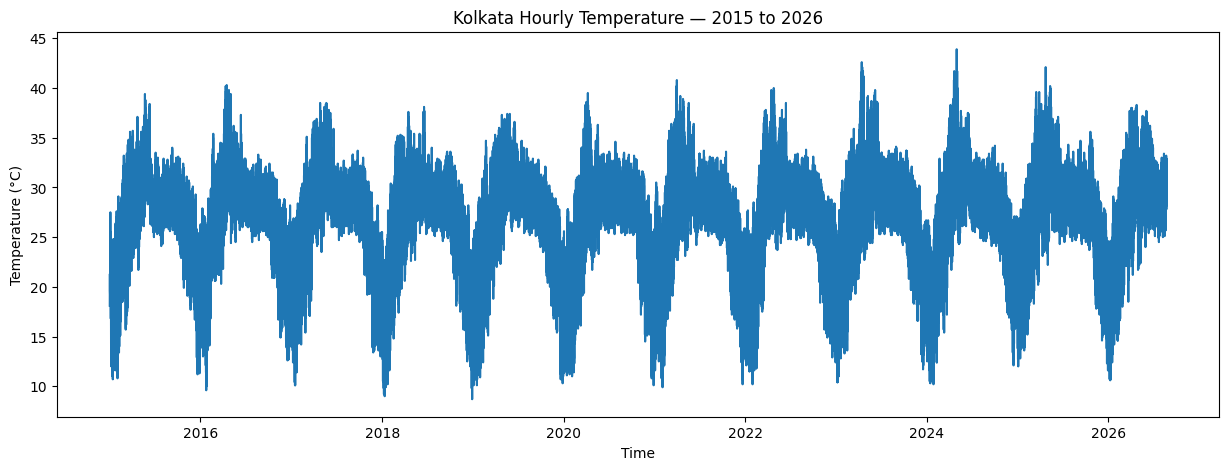

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(df_v2["timestamp"], df_v2["temperature_c"])

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Kolkata Hourly Temperature — 2015 to 2026")

plt.show()

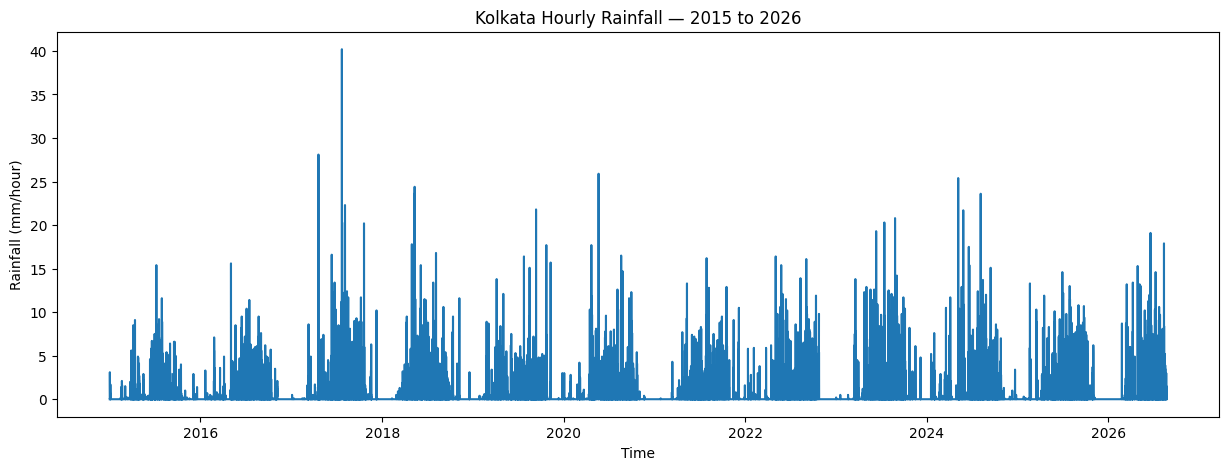

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(
    df_v2["timestamp"],
    df_v2["rainfall_mm"]
)

plt.xlabel("Time")
plt.ylabel("Rainfall (mm/hour)")
plt.title("Kolkata Hourly Rainfall — 2015 to 2026")

plt.show()

In [ ]:
corr = df_v2.drop(columns=["timestamp"]).corr()

display(corr.round(2))

,temperature_c,rainfall_mm,humidity_percent,dew_point_c,pressure_hpa,wind_speed_kmh,wind_direction_deg,cloud_cover_percent
temperature_c,1.00,0.05,-0.34,0.62,-0.62,0.30,-0.06,0.29
rainfall_mm,0.05,1.00,0.14,0.16,-0.20,0.13,-0.04,0.23
humidity_percent,-0.34,0.14,1.00,0.51,-0.27,0.00,-0.19,0.35
dew_point_c,0.62,0.16,0.51,1.00,-0.77,0.29,-0.22,0.55
pressure_hpa,-0.62,-0.20,-0.27,-0.77,1.00,-0.41,0.13,-0.55
wind_speed_kmh,0.30,0.13,0.00,0.29,-0.41,1.00,-0.05,0.21
wind_direction_deg,-0.06,-0.04,-0.19,-0.22,0.13,-0.05,1.00,-0.17
cloud_cover_percent,0.29,0.23,0.35,0.55,-0.55,0.21,-0.17,1.00


In [ ]:
df_v2["month"] = df_v2["timestamp"].dt.month

monthly = df_v2.groupby("month").agg({
    "temperature_c": "mean",
    "rainfall_mm": "mean"
})

display(monthly.round(2))

,temperature_c,rainfall_mm
month,,
1,19.01,0.02
2,22.77,0.04
3,26.83,0.06
4,29.71,0.11
5,29.93,0.21
6,29.72,0.35
7,28.45,0.56
8,28.23,0.52
9,28.09,0.42


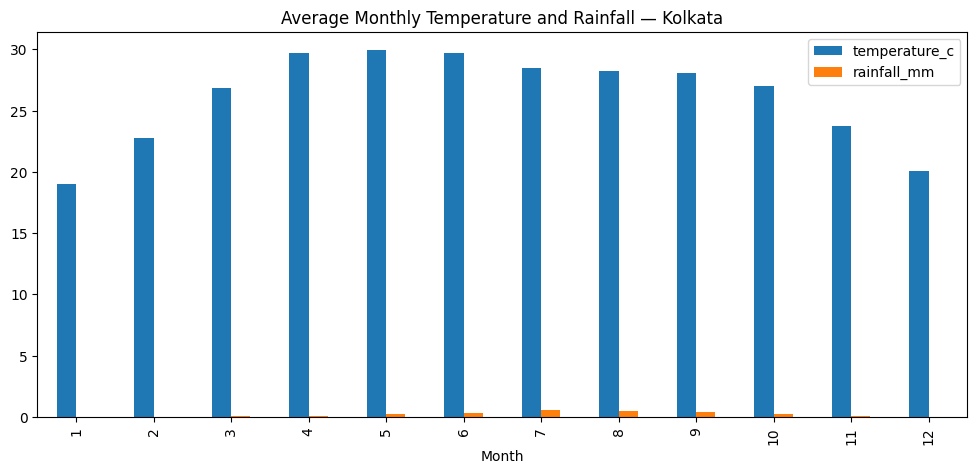

In [ ]:
monthly.plot(
    y=["temperature_c", "rainfall_mm"],
    kind="bar",
    figsize=(12, 5)
)

plt.title("Average Monthly Temperature and Rainfall — Kolkata")
plt.xlabel("Month")
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Make a copy so V2 remains unchanged
df_ml = df_v2.copy()

# --------------------------------------------------
# 1. TIME FEATURES
# --------------------------------------------------

df_ml["hour"] = df_ml["timestamp"].dt.hour
df_ml["day_of_year"] = df_ml["timestamp"].dt.dayofyear
df_ml["month"] = df_ml["timestamp"].dt.month

# Cyclic encoding
df_ml["hour_sin"] = np.sin(2 * np.pi * df_ml["hour"] / 24)
df_ml["hour_cos"] = np.cos(2 * np.pi * df_ml["hour"] / 24)

df_ml["day_sin"] = np.sin(
    2 * np.pi * df_ml["day_of_year"] / 365.25
)

df_ml["day_cos"] = np.cos(
    2 * np.pi * df_ml["day_of_year"] / 365.25
)

# --------------------------------------------------
# 2. WIND DIRECTION
# --------------------------------------------------

wind_rad = np.deg2rad(df_ml["wind_direction_deg"])

df_ml["wind_direction_sin"] = np.sin(wind_rad)
df_ml["wind_direction_cos"] = np.cos(wind_rad)

# --------------------------------------------------
# 3. LAG FEATURES
# --------------------------------------------------

weather_columns = [
    "temperature_c",
    "rainfall_mm",
    "humidity_percent",
    "dew_point_c",
    "pressure_hpa",
    "wind_speed_kmh",
    "cloud_cover_percent"
]

lags = [1, 3, 6, 12, 24]

for column in weather_columns:
    for lag in lags:
        df_ml[f"{column}_lag_{lag}h"] = (
            df_ml[column].shift(lag)
        )

# --------------------------------------------------
# 4. FUTURE TARGETS
# --------------------------------------------------

# Predict weather 6 hours into the future

df_ml["target_temperature_6h"] = (
    df_ml["temperature_c"].shift(-6)
)

df_ml["target_rainfall_6h"] = (
    df_ml["rainfall_mm"].shift(-6)
)

# --------------------------------------------------
# 5. REMOVE UNUSABLE ROWS
# --------------------------------------------------

df_ml.dropna(inplace=True)

df_ml.reset_index(drop=True, inplace=True)

# --------------------------------------------------
# 6. CHECK DATASET
# --------------------------------------------------

print("ML Dataset shape:", df_ml.shape)

print("\nMissing values:")
print(df_ml.isnull().sum().sum())

print("\nFirst 5 rows:")
display(df_ml.head())

ML Dataset shape: (102018, 55)

Missing values:
0

First 5 rows:


,timestamp,temperature_c,rainfall_mm,humidity_percent,dew_point_c,pressure_hpa,wind_speed_kmh,wind_direction_deg,cloud_cover_percent,month,...,wind_speed_kmh_lag_6h,wind_speed_kmh_lag_12h,wind_speed_kmh_lag_24h,cloud_cover_percent_lag_1h,cloud_cover_percent_lag_3h,cloud_cover_percent_lag_6h,cloud_cover_percent_lag_12h,cloud_cover_percent_lag_24h,target_temperature_6h,target_rainfall_6h
0,2015-01-02 00:00:00,19.3,0.0,93,18.2,1014.8,10.8,69,74,1,...,10.4,10.4,9.2,96.0,81.0,92.0,100.0,86.0,19.3,0.0
1,2015-01-02 01:00:00,19.3,0.0,93,18.1,1014.4,10.8,69,100,1,...,11.6,11.5,9.2,74.0,86.0,95.0,100.0,96.0,19.9,0.0
2,2015-01-02 02:00:00,19.3,0.0,92,18.0,1014.2,11.6,68,88,1,...,10.8,13.2,8.7,100.0,96.0,95.0,100.0,90.0,21.5,0.0
3,2015-01-02 03:00:00,19.3,0.0,92,18.0,1014.1,11.8,70,75,1,...,10.8,12.2,8.0,88.0,74.0,81.0,99.0,97.0,23.5,0.0
4,2015-01-02 04:00:00,19.2,0.0,92,17.9,1013.8,11.5,76,59,1,...,11.0,11.8,8.1,75.0,100.0,86.0,88.0,100.0,24.9,0.0


In [ ]:
train_end = "2022-12-31 23:00:00"
val_end = "2024-12-31 23:00:00"

train_df = df_ml[df_ml["timestamp"] <= train_end].copy()

val_df = df_ml[
    (df_ml["timestamp"] > train_end) &
    (df_ml["timestamp"] <= val_end)
].copy()

test_df = df_ml[df_ml["timestamp"] > val_end].copy()

print("TRAIN:", train_df.shape)
print("VALIDATION:", val_df.shape)
print("TEST:", test_df.shape)

TRAIN: (70104, 55)
VALIDATION: (17544, 55)
TEST: (14370, 55)


In [ ]:
import requests
import pandas as pd
import numpy as np

# ==============================
# DELHI LOCATION
# ==============================

LATITUDE = 28.6139
LONGITUDE = 77.2090

START_DATE = "2015-01-01"
END_DATE = "2026-08-22"

URL = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": START_DATE,
    "end_date": END_DATE,

    "hourly": ",".join([
        "temperature_2m",
        "precipitation",
        "relative_humidity_2m",
        "dew_point_2m",
        "pressure_msl",
        "wind_speed_10m",
        "wind_direction_10m",
        "cloud_cover"
    ]),

    "timezone": "Asia/Kolkata",
    "temperature_unit": "celsius",
    "precipitation_unit": "mm",
    "wind_speed_unit": "kmh"
}

print("Downloading Delhi weather data...")

response = requests.get(
    URL,
    params=params,
    timeout=180
)

response.raise_for_status()

data = response.json()

df_delhi_v2 = pd.DataFrame(data["hourly"])

# Rename columns
df_delhi_v2.rename(columns={
    "time": "timestamp",
    "temperature_2m": "temperature_c",
    "precipitation": "rainfall_mm",
    "relative_humidity_2m": "humidity_percent",
    "dew_point_2m": "dew_point_c",
    "pressure_msl": "pressure_hpa",
    "wind_speed_10m": "wind_speed_kmh",
    "wind_direction_10m": "wind_direction_deg",
    "cloud_cover": "cloud_cover_percent"
}, inplace=True)

# Timestamp
df_delhi_v2["timestamp"] = pd.to_datetime(
    df_delhi_v2["timestamp"]
)

# Sort
df_delhi_v2.sort_values(
    "timestamp",
    inplace=True
)

# Remove duplicate timestamps
df_delhi_v2.drop_duplicates(
    subset=["timestamp"],
    inplace=True
)

# Reset index
df_delhi_v2.reset_index(
    drop=True,
    inplace=True
)

# Save
df_delhi_v2.to_csv(
    "delhi_weather_v2.csv",
    index=False
)

print("\nDelhi V2 created!")
print("Shape:", df_delhi_v2.shape)

print("\nColumns:")
print(df_delhi_v2.columns.tolist())

print("\nMissing values:")
print(df_delhi_v2.isnull().sum())

print("\nFirst 5 rows:")
display(df_delhi_v2.head())

print("\nLast 5 rows:")
display(df_delhi_v2.tail())


Delhi V2 created!
Shape: (102048, 9)

Columns:
['timestamp', 'temperature_c', 'rainfall_mm', 'humidity_percent', 'dew_point_c', 'pressure_hpa', 'wind_speed_kmh', 'wind_direction_deg', 'cloud_cover_percent']

Missing values:
timestamp              0
temperature_c          0
rainfall_mm            0
humidity_percent       0
dew_point_c            0
pressure_hpa           0
wind_speed_kmh         0
wind_direction_deg     0
cloud_cover_percent    0
dtype: int64

First 5 rows:


,timestamp,temperature_c,rainfall_mm,humidity_percent,dew_point_c,pressure_hpa,wind_speed_kmh,wind_direction_deg,cloud_cover_percent
0,2015-01-01 00:00:00,12.2,0.0,86,10.0,1017.1,8.2,23,100
1,2015-01-01 01:00:00,12.9,0.0,81,9.8,1016.7,8.9,21,100
2,2015-01-01 02:00:00,13.2,0.0,79,9.7,1016.8,8.0,18,78
3,2015-01-01 03:00:00,13.1,0.0,79,9.6,1016.4,7.1,24,63
4,2015-01-01 04:00:00,13.0,0.0,80,9.6,1015.6,6.7,16,61



Last 5 rows:


,timestamp,temperature_c,rainfall_mm,humidity_percent,dew_point_c,pressure_hpa,wind_speed_kmh,wind_direction_deg,cloud_cover_percent
102043,2026-08-22 19:00:00,28.5,0.1,89,26.5,1001.9,8.9,173,31
102044,2026-08-22 20:00:00,27.9,0.0,89,25.9,1002.4,4.7,187,22
102045,2026-08-22 21:00:00,27.6,0.0,89,25.7,1003.0,4.8,200,47
102046,2026-08-22 22:00:00,27.3,0.0,87,25.0,1003.3,7.3,197,17
102047,2026-08-22 23:00:00,28.5,0.0,85,25.7,1003.2,7.3,171,3


In [ ]:
print("Shape:", df_delhi_v2.shape)

print("\nMissing values:")
print(df_delhi_v2.isnull().sum())

print("\nDuplicate rows:")
print(df_delhi_v2.duplicated().sum())

print("\nTimestamp range:")
print(
    df_delhi_v2["timestamp"].min(),
    "to",
    df_delhi_v2["timestamp"].max()
)

print("\nTemperature statistics:")
print(df_delhi_v2["temperature_c"].describe())

print("\nRainfall statistics:")
print(df_delhi_v2["rainfall_mm"].describe())

print("\nRainy hours:")
print(
    (df_delhi_v2["rainfall_mm"] > 0).sum()
)

print("\nMaximum hourly rainfall:")
print(
    df_delhi_v2["rainfall_mm"].max()
)

Shape: (102048, 9)

Missing values:
timestamp              0
temperature_c          0
rainfall_mm            0
humidity_percent       0
dew_point_c            0
pressure_hpa           0
wind_speed_kmh         0
wind_direction_deg     0
cloud_cover_percent    0
dtype: int64

Duplicate rows:
0

Timestamp range:
2015-01-01 00:00:00 to 2026-08-22 23:00:00

Temperature statistics:
count    102048.000000
mean         24.725637
std           7.985430
min           2.000000
25%          18.800000
50%          26.100000
75%          30.300000
max          46.000000
Name: temperature_c, dtype: float64

Rainfall statistics:
count    102048.000000
mean          0.087911
std           0.587616
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          30.400000
Name: rainfall_mm, dtype: float64

Rainy hours:
10099

Maximum hourly rainfall:
30.4


In [ ]:
time_diff = (
    df_delhi_v2["timestamp"]
    .diff()
    .dropna()
)

print(time_diff.value_counts().head())

timestamp
0 days 01:00:00    102047
Name: count, dtype: int64


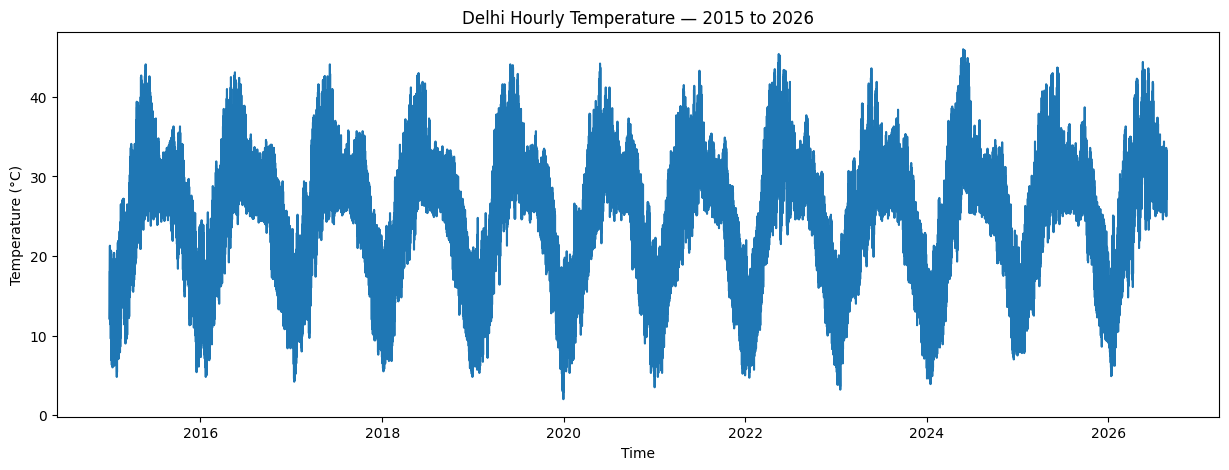

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(
    df_delhi_v2["timestamp"],
    df_delhi_v2["temperature_c"]
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Delhi Hourly Temperature — 2015 to 2026")

plt.show()

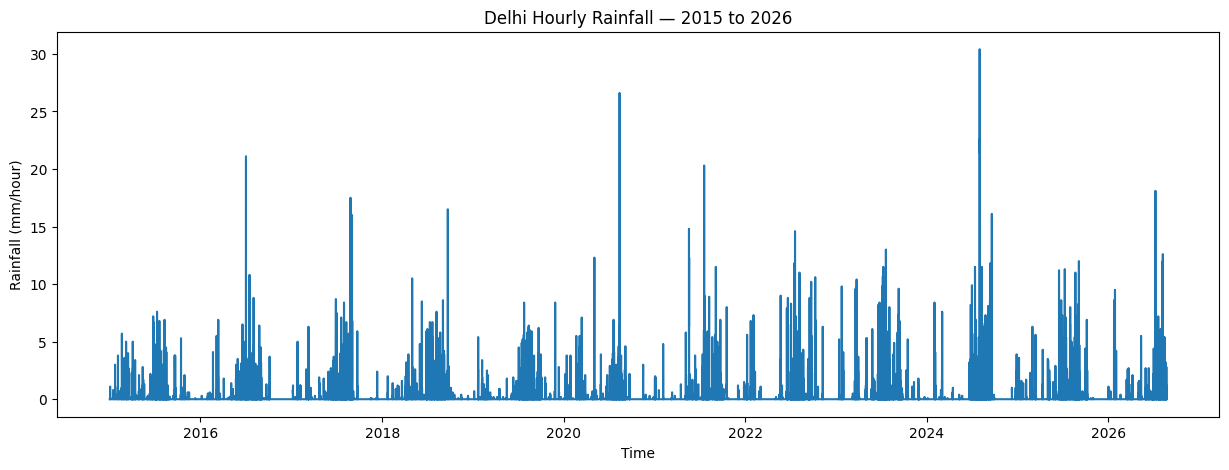

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(
    df_delhi_v2["timestamp"],
    df_delhi_v2["rainfall_mm"]
)

plt.xlabel("Time")
plt.ylabel("Rainfall (mm/hour)")
plt.title("Delhi Hourly Rainfall — 2015 to 2026")

plt.show()

In [ ]:
corr_delhi = (
    df_delhi_v2
    .drop(columns=["timestamp"])
    .corr()
)

display(corr_delhi.round(2))

,temperature_c,rainfall_mm,humidity_percent,dew_point_c,pressure_hpa,wind_speed_kmh,wind_direction_deg,cloud_cover_percent
temperature_c,1.00,0.02,-0.56,0.46,-0.78,0.19,-0.12,0.11
rainfall_mm,0.02,1.00,0.16,0.16,-0.12,0.03,-0.10,0.22
humidity_percent,-0.56,0.16,1.00,0.44,0.13,-0.26,-0.25,0.29
dew_point_c,0.46,0.16,0.44,1.00,-0.66,-0.09,-0.39,0.39
pressure_hpa,-0.78,-0.12,0.13,-0.66,1.00,-0.13,0.24,-0.26
wind_speed_kmh,0.19,0.03,-0.26,-0.09,-0.13,1.00,0.08,-0.02
wind_direction_deg,-0.12,-0.10,-0.25,-0.39,0.24,0.08,1.00,-0.25
cloud_cover_percent,0.11,0.22,0.29,0.39,-0.26,-0.02,-0.25,1.00


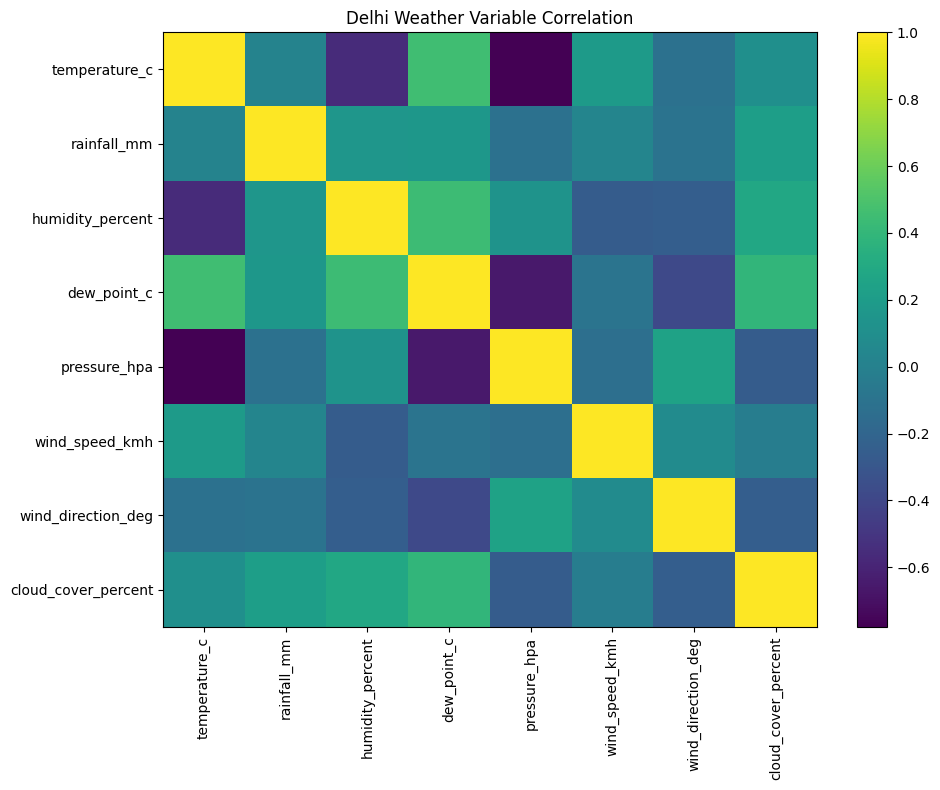

In [ ]:
plt.figure(figsize=(10, 8))

plt.imshow(
    corr_delhi,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(corr_delhi.columns)),
    corr_delhi.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_delhi.columns)),
    corr_delhi.columns
)

plt.title("Delhi Weather Variable Correlation")

plt.tight_layout()
plt.show()

In [ ]:
df_delhi_v2["month"] = (
    df_delhi_v2["timestamp"].dt.month
)

monthly_delhi = (
    df_delhi_v2
    .groupby("month")
    .agg({
        "temperature_c": "mean",
        "rainfall_mm": "mean"
    })
)

display(monthly_delhi.round(2))

,temperature_c,rainfall_mm
month,,
1,13.05,0.04
2,17.36,0.03
3,22.67,0.04
4,29.22,0.02
5,32.10,0.05
6,32.90,0.09
7,29.85,0.33
8,28.91,0.24
9,28.47,0.17


In [ ]:
df_delhi_ml = df_delhi_v2.copy()

# ==============================
# TIME FEATURES
# ==============================

df_delhi_ml["hour"] = (
    df_delhi_ml["timestamp"].dt.hour
)

df_delhi_ml["day_of_year"] = (
    df_delhi_ml["timestamp"].dt.dayofyear
)

df_delhi_ml["month"] = (
    df_delhi_ml["timestamp"].dt.month
)

# Cyclic hour
df_delhi_ml["hour_sin"] = np.sin(
    2 * np.pi * df_delhi_ml["hour"] / 24
)

df_delhi_ml["hour_cos"] = np.cos(
    2 * np.pi * df_delhi_ml["hour"] / 24
)

# Cyclic day of year
df_delhi_ml["day_sin"] = np.sin(
    2 * np.pi *
    df_delhi_ml["day_of_year"] /
    365.25
)

df_delhi_ml["day_cos"] = np.cos(
    2 * np.pi *
    df_delhi_ml["day_of_year"] /
    365.25
)

# ==============================
# WIND DIRECTION
# ==============================

wind_rad = np.deg2rad(
    df_delhi_ml["wind_direction_deg"]
)

df_delhi_ml["wind_direction_sin"] = np.sin(
    wind_rad
)

df_delhi_ml["wind_direction_cos"] = np.cos(
    wind_rad
)

# ==============================
# LAG FEATURES
# ==============================

weather_columns = [
    "temperature_c",
    "rainfall_mm",
    "humidity_percent",
    "dew_point_c",
    "pressure_hpa",
    "wind_speed_kmh",
    "cloud_cover_percent"
]

lags = [1, 3, 6, 12, 24]

for column in weather_columns:

    for lag in lags:

        df_delhi_ml[
            f"{column}_lag_{lag}h"
        ] = (
            df_delhi_ml[column]
            .shift(lag)
        )

# ==============================
# 6-HOUR FUTURE TARGETS
# ==============================

df_delhi_ml["target_temperature_6h"] = (
    df_delhi_ml["temperature_c"].shift(-6)
)

df_delhi_ml["target_rainfall_6h"] = (
    df_delhi_ml["rainfall_mm"].shift(-6)
)

# ==============================
# REMOVE NaN
# ==============================

df_delhi_ml.dropna(inplace=True)

df_delhi_ml.reset_index(
    drop=True,
    inplace=True
)

print("Delhi ML dataset:")
print(df_delhi_ml.shape)

print("\nMissing values:")
print(df_delhi_ml.isnull().sum().sum())

Delhi ML dataset:
(102018, 55)

Missing values:
0


In [ ]:
df_delhi_ml["location"] = "Delhi"
df_delhi_ml["latitude"] = 28.6139
df_delhi_ml["longitude"] = 77.2090

In [ ]:
df_ml["location"] = "Kolkata"
df_ml["latitude"] = 22.5726
df_ml["longitude"] = 88.3639

In [ ]:
df_delhi_ml.to_csv(
    "delhi_weather_ml_v3.csv",
    index=False
)

print("Delhi V3 saved successfully!")

Delhi V3 saved successfully!


In [ ]:
from google.colab import files

files.download(
    "delhi_weather_ml_v3.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Save Kolkata V3
df_ml.to_csv(
    "kolkata_weather_ml_v3.csv",
    index=False
)

print("Kolkata V3 saved!")
print("Shape:", df_ml.shape)

Kolkata V3 saved!
Shape: (102018, 58)


In [ ]:
from google.colab import files

files.download("kolkata_weather_ml_v3.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import requests
import pandas as pd
import numpy as np

# ==========================================
# MUMBAI LOCATION
# ==========================================

LATITUDE = 19.0760
LONGITUDE = 72.8777

START_DATE = "2015-01-01"
END_DATE = "2026-08-22"

URL = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": START_DATE,
    "end_date": END_DATE,

    "hourly": ",".join([
        "temperature_2m",
        "precipitation",
        "relative_humidity_2m",
        "dew_point_2m",
        "pressure_msl",
        "wind_speed_10m",
        "wind_direction_10m",
        "cloud_cover"
    ]),

    "timezone": "Asia/Kolkata",
    "temperature_unit": "celsius",
    "precipitation_unit": "mm",
    "wind_speed_unit": "kmh"
}

print("Downloading Mumbai weather data...")

response = requests.get(
    URL,
    params=params,
    timeout=180
)

response.raise_for_status()

data = response.json()

df_mumbai_v2 = pd.DataFrame(data["hourly"])

# Rename columns
df_mumbai_v2.rename(columns={
    "time": "timestamp",
    "temperature_2m": "temperature_c",
    "precipitation": "rainfall_mm",
    "relative_humidity_2m": "humidity_percent",
    "dew_point_2m": "dew_point_c",
    "pressure_msl": "pressure_hpa",
    "wind_speed_10m": "wind_speed_kmh",
    "wind_direction_10m": "wind_direction_deg",
    "cloud_cover": "cloud_cover_percent"
}, inplace=True)

# Convert timestamp
df_mumbai_v2["timestamp"] = pd.to_datetime(
    df_mumbai_v2["timestamp"]
)

# Sort chronologically
df_mumbai_v2.sort_values(
    "timestamp",
    inplace=True
)

# Remove duplicate timestamps
df_mumbai_v2.drop_duplicates(
    subset=["timestamp"],
    inplace=True
)

# Reset index
df_mumbai_v2.reset_index(
    drop=True,
    inplace=True
)

# Save V2
df_mumbai_v2.to_csv(
    "mumbai_weather_v2.csv",
    index=False
)

print("\nMumbai V2 created successfully!")
print("Shape:", df_mumbai_v2.shape)

print("\nColumns:")
print(df_mumbai_v2.columns.tolist())

print("\nMissing values:")
print(df_mumbai_v2.isnull().sum())

print("\nFirst 5 rows:")
display(df_mumbai_v2.head())

print("\nLast 5 rows:")
display(df_mumbai_v2.tail())


Mumbai V2 created successfully!
Shape: (102048, 9)

Columns:
['timestamp', 'temperature_c', 'rainfall_mm', 'humidity_percent', 'dew_point_c', 'pressure_hpa', 'wind_speed_kmh', 'wind_direction_deg', 'cloud_cover_percent']

Missing values:
timestamp              0
temperature_c          0
rainfall_mm            0
humidity_percent       0
dew_point_c            0
pressure_hpa           0
wind_speed_kmh         0
wind_direction_deg     0
cloud_cover_percent    0
dtype: int64

First 5 rows:


,timestamp,temperature_c,rainfall_mm,humidity_percent,dew_point_c,pressure_hpa,wind_speed_kmh,wind_direction_deg,cloud_cover_percent
0,2015-01-01 00:00:00,21.5,0.0,72,16.2,1009.3,8.2,23,66
1,2015-01-01 01:00:00,21.2,0.0,73,16.2,1008.9,7.9,30,70
2,2015-01-01 02:00:00,20.8,0.0,75,16.2,1008.3,8.5,36,74
3,2015-01-01 03:00:00,20.4,0.0,77,16.2,1008.1,7.4,47,50
4,2015-01-01 04:00:00,20.0,0.0,79,16.2,1008.1,6.9,62,34



Last 5 rows:


,timestamp,temperature_c,rainfall_mm,humidity_percent,dew_point_c,pressure_hpa,wind_speed_kmh,wind_direction_deg,cloud_cover_percent
102043,2026-08-22 19:00:00,27.2,0.1,85,24.6,1007.0,13.5,269,93
102044,2026-08-22 20:00:00,26.6,0.3,85,23.9,1007.6,10.8,266,100
102045,2026-08-22 21:00:00,26.0,0.7,89,24.0,1008.2,9.7,272,100
102046,2026-08-22 22:00:00,26.5,0.3,89,24.5,1008.4,8.8,268,100
102047,2026-08-22 23:00:00,27.0,0.3,85,24.2,1007.9,13.4,252,99


In [ ]:
print("Shape:", df_mumbai_v2.shape)

print("\nMissing values:")
print(df_mumbai_v2.isnull().sum())

print("\nDuplicate rows:")
print(df_mumbai_v2.duplicated().sum())

print("\nTimestamp range:")
print(
    df_mumbai_v2["timestamp"].min(),
    "to",
    df_mumbai_v2["timestamp"].max()
)

print("\nTemperature statistics:")
print(df_mumbai_v2["temperature_c"].describe())

print("\nRainfall statistics:")
print(df_mumbai_v2["rainfall_mm"].describe())

rain_hours = (
    df_mumbai_v2["rainfall_mm"] > 0
).sum()

print("\nRainy hours:", rain_hours)

print(
    "Rainy percentage:",
    round(rain_hours / len(df_mumbai_v2) * 100, 2),
    "%"
)

print(
    "\nMaximum hourly rainfall:",
    df_mumbai_v2["rainfall_mm"].max()
)

Shape: (102048, 9)

Missing values:
timestamp              0
temperature_c          0
rainfall_mm            0
humidity_percent       0
dew_point_c            0
pressure_hpa           0
wind_speed_kmh         0
wind_direction_deg     0
cloud_cover_percent    0
dtype: int64

Duplicate rows:
0

Timestamp range:
2015-01-01 00:00:00 to 2026-08-22 23:00:00

Temperature statistics:
count    102048.000000
mean         26.862249
std           3.322329
min          13.000000
25%          25.300000
50%          26.800000
75%          28.800000
max          41.300000
Name: temperature_c, dtype: float64

Rainfall statistics:
count    102048.000000
mean          0.264950
std           0.994132
min           0.000000
25%           0.000000
50%           0.000000
75%           0.100000
max          47.600000
Name: rainfall_mm, dtype: float64

Rainy hours: 29534
Rainy percentage: 28.94 %

Maximum hourly rainfall: 47.6


In [ ]:
time_diff = (
    df_mumbai_v2["timestamp"]
    .diff()
    .dropna()
)

print(time_diff.value_counts().head())

timestamp
0 days 01:00:00    102047
Name: count, dtype: int64


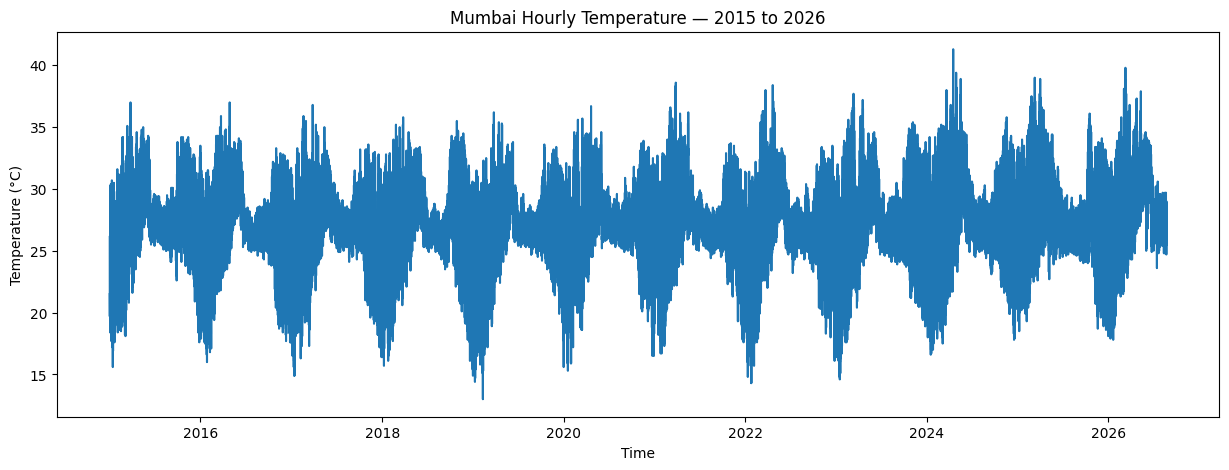

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(
    df_mumbai_v2["timestamp"],
    df_mumbai_v2["temperature_c"]
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Mumbai Hourly Temperature — 2015 to 2026")

plt.show()

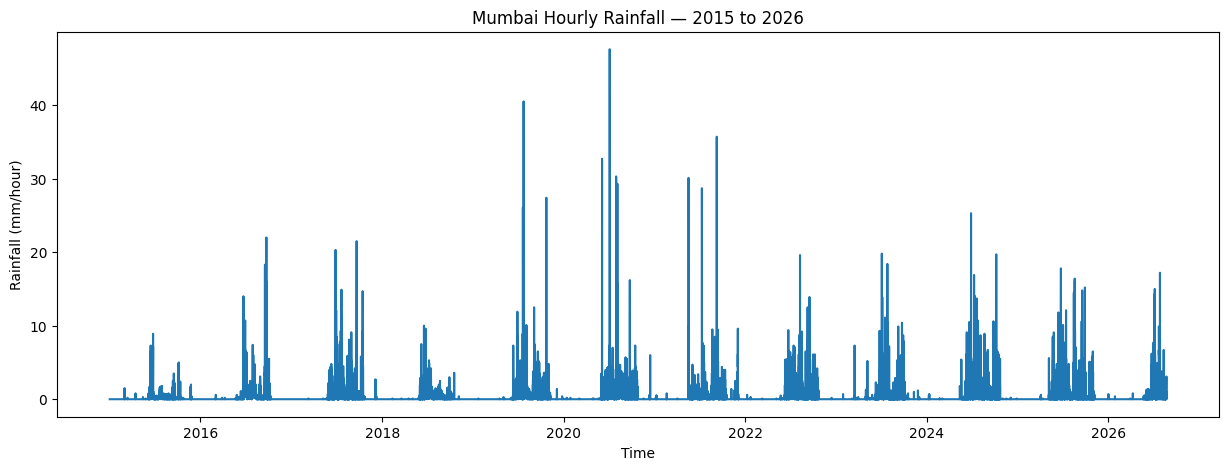

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(
    df_mumbai_v2["timestamp"],
    df_mumbai_v2["rainfall_mm"]
)

plt.xlabel("Time")
plt.ylabel("Rainfall (mm/hour)")
plt.title("Mumbai Hourly Rainfall — 2015 to 2026")

plt.show()

In [ ]:
corr_mumbai = (
    df_mumbai_v2
    .drop(columns=["timestamp"])
    .corr()
)

display(corr_mumbai.round(2))

,temperature_c,rainfall_mm,humidity_percent,dew_point_c,pressure_hpa,wind_speed_kmh,wind_direction_deg,cloud_cover_percent
temperature_c,1.00,-0.04,-0.41,0.26,-0.27,0.23,0.38,0.01
rainfall_mm,-0.04,1.00,0.24,0.20,-0.33,0.25,0.05,0.32
humidity_percent,-0.41,0.24,1.00,0.76,-0.46,-0.02,-0.08,0.48
dew_point_c,0.26,0.20,0.76,1.00,-0.66,0.16,0.20,0.48
pressure_hpa,-0.27,-0.33,-0.46,-0.66,1.00,-0.45,-0.24,-0.56
wind_speed_kmh,0.23,0.25,-0.02,0.16,-0.45,1.00,0.34,0.23
wind_direction_deg,0.38,0.05,-0.08,0.20,-0.24,0.34,1.00,0.05
cloud_cover_percent,0.01,0.32,0.48,0.48,-0.56,0.23,0.05,1.00


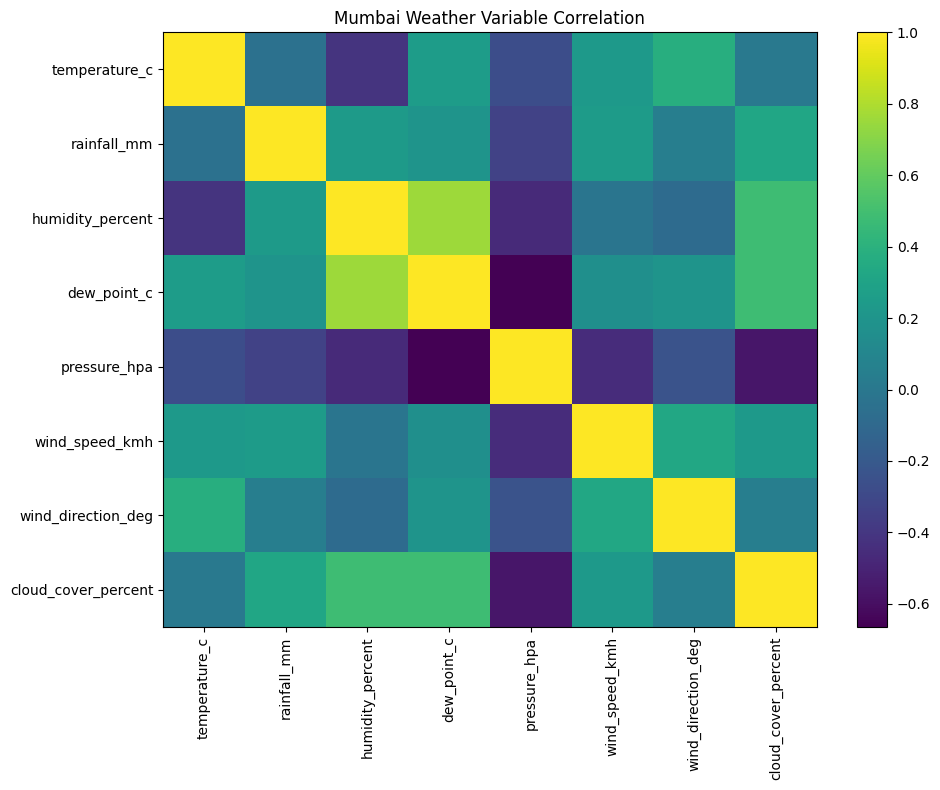

In [ ]:
plt.figure(figsize=(10, 8))

plt.imshow(
    corr_mumbai,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(corr_mumbai.columns)),
    corr_mumbai.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_mumbai.columns)),
    corr_mumbai.columns
)

plt.title("Mumbai Weather Variable Correlation")

plt.tight_layout()
plt.show()

In [ ]:
df_mumbai_v2["month"] = (
    df_mumbai_v2["timestamp"].dt.month
)

monthly_mumbai = (
    df_mumbai_v2
    .groupby("month")
    .agg({
        "temperature_c": "mean",
        "rainfall_mm": "mean"
    })
)

display(monthly_mumbai.round(2))

,temperature_c,rainfall_mm
month,,
1,23.67,0.00
2,25.17,0.00
3,27.22,0.00
4,28.69,0.00
5,29.76,0.06
6,28.25,0.63
7,26.73,1.07
8,26.55,0.60
9,26.61,0.60


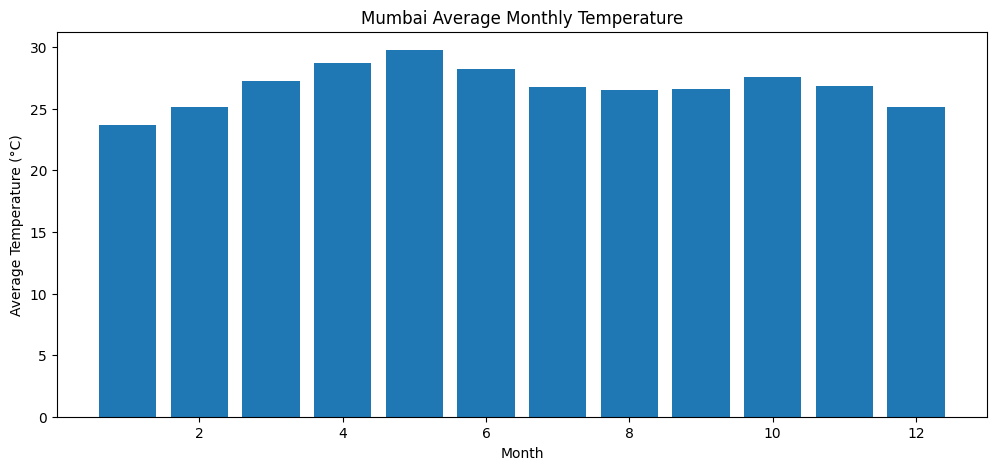

In [ ]:
plt.figure(figsize=(12, 5))

plt.bar(
    monthly_mumbai.index,
    monthly_mumbai["temperature_c"]
)

plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.title("Mumbai Average Monthly Temperature")

plt.show()

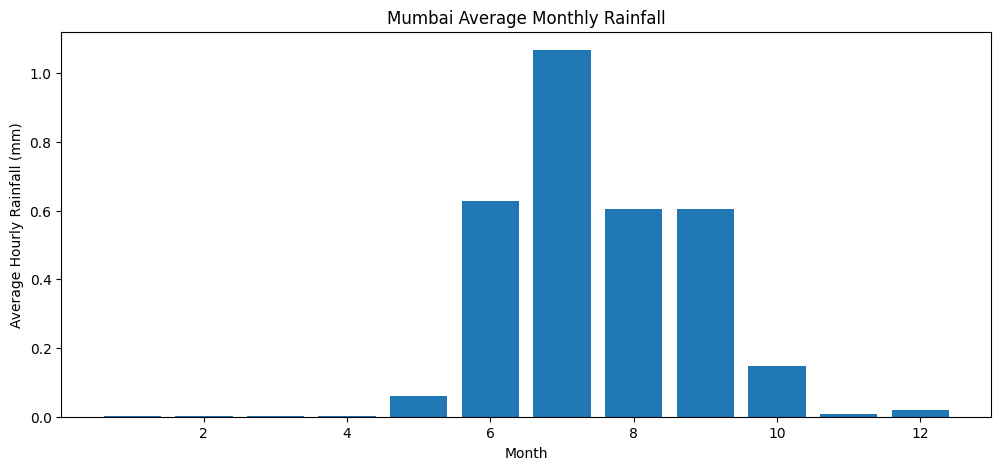

In [ ]:
plt.figure(figsize=(12, 5))

plt.bar(
    monthly_mumbai.index,
    monthly_mumbai["rainfall_mm"]
)

plt.xlabel("Month")
plt.ylabel("Average Hourly Rainfall (mm)")
plt.title("Mumbai Average Monthly Rainfall")

plt.show()

In [ ]:
df_mumbai_ml = df_mumbai_v2.copy()

# ==========================================
# TIME FEATURES
# ==========================================

df_mumbai_ml["hour"] = (
    df_mumbai_ml["timestamp"].dt.hour
)

df_mumbai_ml["day_of_year"] = (
    df_mumbai_ml["timestamp"].dt.dayofyear
)

df_mumbai_ml["month"] = (
    df_mumbai_ml["timestamp"].dt.month
)

# Cyclic hour
df_mumbai_ml["hour_sin"] = np.sin(
    2 * np.pi * df_mumbai_ml["hour"] / 24
)

df_mumbai_ml["hour_cos"] = np.cos(
    2 * np.pi * df_mumbai_ml["hour"] / 24
)

# Cyclic day of year
df_mumbai_ml["day_sin"] = np.sin(
    2 * np.pi *
    df_mumbai_ml["day_of_year"] /
    365.25
)

df_mumbai_ml["day_cos"] = np.cos(
    2 * np.pi *
    df_mumbai_ml["day_of_year"] /
    365.25
)

# ==========================================
# WIND DIRECTION
# ==========================================

wind_rad = np.deg2rad(
    df_mumbai_ml["wind_direction_deg"]
)

df_mumbai_ml["wind_direction_sin"] = np.sin(
    wind_rad
)

df_mumbai_ml["wind_direction_cos"] = np.cos(
    wind_rad
)

# ==========================================
# LAG FEATURES
# ==========================================

weather_columns = [
    "temperature_c",
    "rainfall_mm",
    "humidity_percent",
    "dew_point_c",
    "pressure_hpa",
    "wind_speed_kmh",
    "cloud_cover_percent"
]

lags = [1, 3, 6, 12, 24]

for column in weather_columns:

    for lag in lags:

        df_mumbai_ml[
            f"{column}_lag_{lag}h"
        ] = (
            df_mumbai_ml[column]
            .shift(lag)
        )

# ==========================================
# 6-HOUR FUTURE TARGETS
# ==========================================

df_mumbai_ml["target_temperature_6h"] = (
    df_mumbai_ml["temperature_c"].shift(-6)
)

df_mumbai_ml["target_rainfall_6h"] = (
    df_mumbai_ml["rainfall_mm"].shift(-6)
)

# ==========================================
# REMOVE NaN
# ==========================================

df_mumbai_ml.dropna(
    inplace=True
)

df_mumbai_ml.reset_index(
    drop=True,
    inplace=True
)

print("Mumbai ML dataset:")
print(df_mumbai_ml.shape)

print("\nMissing values:")
print(
    df_mumbai_ml.isnull().sum().sum()
)

Mumbai ML dataset:
(102018, 55)

Missing values:
0


In [ ]:
df_mumbai_ml.to_csv(
    "mumbai_weather_ml_v3.csv",
    index=False
)

print("Mumbai V3 saved successfully!")
print("Shape:", df_mumbai_ml.shape)

Mumbai V3 saved successfully!
Shape: (102018, 55)


In [ ]:
for i in range(5):

    sample_X = X_test.iloc[[i]]

    result = forecast_weather(sample_X)

    print(f"\nForecast {i+1}")
    print("-" * 30)
    print(f"Temperature      : {result['temperature_6h']:.2f} °C")
    print(f"Rain probability : {result['rain_probability'] * 100:.2f}%")
    print(f"Rainfall         : {result['rainfall_6h_mm']:.2f} mm")


Forecast 1
------------------------------
Temperature      : 27.44 °C
Rain probability : 87.02%
Rainfall         : 1.11 mm

Forecast 2
------------------------------
Temperature      : 26.43 °C
Rain probability : 87.63%
Rainfall         : 0.91 mm

Forecast 3
------------------------------
Temperature      : 26.11 °C
Rain probability : 92.14%
Rainfall         : 1.36 mm

Forecast 4
------------------------------
Temperature      : 25.90 °C
Rain probability : 95.70%
Rainfall         : 1.36 mm

Forecast 5
------------------------------
Temperature      : 25.81 °C
Rain probability : 91.00%
Rainfall         : 2.26 mm


In [ ]:
# ============================================================
# DETAILED TEMPERATURE EVALUATION
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

temp_pred = temp_model.predict(X_test)

mae = mean_absolute_error(
    y_temp_test,
    temp_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_temp_test,
        temp_pred
    )
)

print("TEMPERATURE MODEL")
print("=================")
print(f"MAE  : {mae:.4f} °C")
print(f"RMSE : {rmse:.4f} °C")

TEMPERATURE MODEL
MAE  : 0.9596 °C
RMSE : 1.3029 °C


In [ ]:
# ============================================================
# PERSISTENCE BASELINE
# ============================================================

baseline_pred = df_test["temperature_c"]

baseline_mae = mean_absolute_error(
    y_temp_test,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_temp_test,
        baseline_pred
    )
)

print("PERSISTENCE BASELINE")
print("====================")
print(f"MAE  : {baseline_mae:.4f} °C")
print(f"RMSE : {baseline_rmse:.4f} °C")

PERSISTENCE BASELINE
MAE  : 3.7023 °C
RMSE : 4.6097 °C


In [ ]:
print("\nMODEL IMPROVEMENT")
print("=================")

mae_improvement = (
    (baseline_mae - mae)
    / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - rmse)
    / baseline_rmse
) * 100

print(
    f"MAE improvement : {mae_improvement:.2f}%"
)

print(
    f"RMSE improvement: {rmse_improvement:.2f}%"
)


MODEL IMPROVEMENT
MAE improvement : 74.08%
RMSE improvement: 71.74%


In [ ]:

print(df_master["location"].value_counts().sort_index())

print("\nMissing values:",
      df_master.isnull().sum().sum())

print("\nDuplicate location+timestamp:",
      df_master.duplicated(
          ["location", "timestamp"]
      ).sum())

location
Ahmedabad      102018
Bengaluru      102018
Bhubaneswar    102018
Chennai        102018
Delhi          102018
Guwahati       102018
Hyderabad      102018
Kolkata        102018
Mumbai         102018
Srinagar       102018
Name: count, dtype: int64

Missing values: 0

Duplicate location+timestamp: 0


In [ ]:
train_parts = []
val_parts = []
test_parts = []

for location, group in df_master.groupby("location"):

    group = group.sort_values("timestamp").reset_index(drop=True)

    n = len(group)

    train_end = int(n * 0.80)
    val_end = int(n * 0.90)

    train_parts.append(
        group.iloc[:train_end]
    )

    val_parts.append(
        group.iloc[train_end:val_end]
    )

    test_parts.append(
        group.iloc[val_end:]
    )

df_train = pd.concat(
    train_parts,
    ignore_index=True
)

df_val = pd.concat(
    val_parts,
    ignore_index=True
)

df_test = pd.concat(
    test_parts,
    ignore_index=True
)

print("TRAIN:", df_train.shape)
print("VALIDATION:", df_val.shape)
print("TEST:", df_test.shape)

TRAIN: (816140, 58)
VALIDATION: (102020, 58)
TEST: (102020, 58)


In [ ]:
DROP_COLUMNS = [
    "timestamp",
    "target_temperature_6h",
    "target_rainfall_6h"
]

FEATURE_COLUMNS = [
    c for c in df_train.columns
    if c not in DROP_COLUMNS
]

X_train = pd.get_dummies(
    df_train[FEATURE_COLUMNS],
    columns=["location"],
    dtype=int
)

X_val = pd.get_dummies(
    df_val[FEATURE_COLUMNS],
    columns=["location"],
    dtype=int
)

X_test = pd.get_dummies(
    df_test[FEATURE_COLUMNS],
    columns=["location"],
    dtype=int
)

X_val = X_val.reindex(
    columns=X_train.columns,
    fill_value=0
)

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(816140, 64)
(102020, 64)
(102020, 64)


In [ ]:
y_temp_train = df_train["target_temperature_6h"]
y_temp_val = df_val["target_temperature_6h"]
y_temp_test = df_test["target_temperature_6h"]

In [ ]:
from xgboost import XGBRegressor

temp_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="mae",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

temp_model.fit(
    X_train,
    y_temp_train,
    eval_set=[
        (X_val, y_temp_val)
    ],
    verbose=100
)

[0]	validation_0-mae:6.33458
[100]	validation_0-mae:1.10540
[200]	validation_0-mae:1.06764
[300]	validation_0-mae:1.05629
[400]	validation_0-mae:1.04936
[500]	validation_0-mae:1.04452
[600]	validation_0-mae:1.04194
[700]	validation_0-mae:1.04007
[800]	validation_0-mae:1.03877
[900]	validation_0-mae:1.03694
[999]	validation_0-mae:1.03571


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric='mae', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

temp_pred = temp_model.predict(X_test)

mae = mean_absolute_error(
    y_temp_test,
    temp_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_temp_test,
        temp_pred
    )
)

print("10-CITY XGBOOST")
print("================")
print(f"MAE  : {mae:.4f} °C")
print(f"RMSE : {rmse:.4f} °C")

10-CITY XGBOOST
MAE  : 0.9886 °C
RMSE : 1.3419 °C


In [ ]:

results = df_test[
    ["location", "target_temperature_6h"]
].copy()

results["prediction"] = temp_pred

city_results = []

for location, group in results.groupby("location"):

    city_mae = mean_absolute_error(
        group["target_temperature_6h"],
        group["prediction"]
    )

    city_rmse = np.sqrt(
        mean_squared_error(
            group["target_temperature_6h"],
            group["prediction"]
        )
    )

    city_results.append({
        "location": location,
        "MAE_C": city_mae,
        "RMSE_C": city_rmse,
        "samples": len(group)
    })

city_results = pd.DataFrame(
    city_results
).sort_values("MAE_C")

display(city_results.round(3))

,location,MAE_C,RMSE_C,samples
8,Mumbai,0.686,0.891,10202
2,Bhubaneswar,0.760,1.050,10202
5,Guwahati,0.797,1.083,10202
1,Bengaluru,0.799,1.078,10202
3,Chennai,0.825,1.112,10202
6,Hyderabad,1.107,1.443,10202
4,Delhi,1.150,1.529,10202
0,Ahmedabad,1.199,1.562,10202
7,Kolkata,1.279,1.684,10202
9,Srinagar,1.284,1.687,10202


In [ ]:
# ============================================================
# RAIN / NO-RAIN TARGET
# ============================================================

RAIN_THRESHOLD = 0.1

y_rain_train = (
    df_train["target_rainfall_6h"] >= RAIN_THRESHOLD
).astype(int)

y_rain_val = (
    df_val["target_rainfall_6h"] >= RAIN_THRESHOLD
).astype(int)

y_rain_test = (
    df_test["target_rainfall_6h"] >= RAIN_THRESHOLD
).astype(int)

print("TRAIN:")
print(y_rain_train.value_counts())

print("\nVALIDATION:")
print(y_rain_val.value_counts())

print("\nTEST:")
print(y_rain_test.value_counts())

TRAIN:
target_rainfall_6h
0    666999
1    149141
Name: count, dtype: int64

VALIDATION:
target_rainfall_6h
0    83343
1    18677
Name: count, dtype: int64

TEST:
target_rainfall_6h
0    79989
1    22031
Name: count, dtype: int64


In [ ]:

from xgboost import XGBClassifier

negative = (y_rain_train == 0).sum()
positive = (y_rain_train == 1).sum()

scale_pos_weight = negative / positive

print("No rain:", negative)
print("Rain:", positive)
print("Scale pos weight:", scale_pos_weight)

rain_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

rain_model.fit(
    X_train,
    y_rain_train,
    eval_set=[
        (X_val, y_rain_val)
    ],
    verbose=100
)

No rain: 666999
Rain: 149141
Scale pos weight: 4.472271206442226
[0]	validation_0-auc:0.87618
[100]	validation_0-auc:0.90017
[200]	validation_0-auc:0.90344
[300]	validation_0-auc:0.90497
[400]	validation_0-auc:0.90537
[500]	validation_0-auc:0.90572
[600]	validation_0-auc:0.90589
[700]	validation_0-auc:0.90590
[800]	validation_0-auc:0.90569
[900]	validation_0-auc:0.90561
[999]	validation_0-auc:0.90552


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

rain_probability = rain_model.predict_proba(X_test)[:, 1]

rain_pred = (
    rain_probability >= 0.5
).astype(int)

print("\nRAIN / NO-RAIN PERFORMANCE")
print("==========================")

print(
    "Accuracy :",
    round(accuracy_score(y_rain_test, rain_pred), 4)
)

print(
    "Precision:",
    round(precision_score(
        y_rain_test,
        rain_pred,
        zero_division=0
    ), 4)
)

print(
    "Recall   :",
    round(recall_score(
        y_rain_test,
        rain_pred,
        zero_division=0
    ), 4)
)

print(
    "F1       :",
    round(f1_score(
        y_rain_test,
        rain_pred,
        zero_division=0
    ), 4)
)

print(
    "ROC-AUC  :",
    round(roc_auc_score(
        y_rain_test,
        rain_probability
    ), 4)
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_rain_test,
        rain_pred
    )
)


RAIN / NO-RAIN PERFORMANCE
Accuracy : 0.8179
Precision: 0.5547
Recall   : 0.7942
F1       : 0.6532
ROC-AUC  : 0.8968

Confusion Matrix:
[[65942 14047]
 [ 4533 17498]]


In [ ]:
# ============================================================
# PREPARE RAINFALL AMOUNT DATA
# ============================================================

RAIN_THRESHOLD = 0.1

train_mask = (
    df_train["target_rainfall_6h"] >= RAIN_THRESHOLD
)

val_mask = (
    df_val["target_rainfall_6h"] >= RAIN_THRESHOLD
)

test_mask = (
    df_test["target_rainfall_6h"] >= RAIN_THRESHOLD
)

X_rain_train = X_train.loc[train_mask]
X_rain_val = X_val.loc[val_mask]
X_rain_test = X_test.loc[test_mask]

y_rain_amount_train = df_train.loc[
    train_mask,
    "target_rainfall_6h"
]

y_rain_amount_val = df_val.loc[
    val_mask,
    "target_rainfall_6h"
]

y_rain_amount_test = df_test.loc[
    test_mask,
    "target_rainfall_6h"
]

print("Rainfall amount samples:")
print("Train:", len(X_rain_train))
print("Validation:", len(X_rain_val))
print("Test:", len(X_rain_test))

Rainfall amount samples:
Train: 149141
Validation: 18677
Test: 22031


In [ ]:

# ============================================================
# XGBOOST RAINFALL AMOUNT MODEL
# ============================================================

rain_amount_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="mae",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

rain_amount_model.fit(
    X_rain_train,
    y_rain_amount_train,
    eval_set=[
        (X_rain_val, y_rain_amount_val)
    ],
    verbose=100
)

[0]	validation_0-mae:1.01498
[100]	validation_0-mae:0.96488
[200]	validation_0-mae:0.96693
[300]	validation_0-mae:0.96777
[400]	validation_0-mae:0.97115
[500]	validation_0-mae:0.97481
[600]	validation_0-mae:0.97773
[700]	validation_0-mae:0.98087
[800]	validation_0-mae:0.98452
[900]	validation_0-mae:0.98680
[999]	validation_0-mae:0.98944


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric='mae', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
# ============================================================
# RAINFALL AMOUNT EVALUATION
# ============================================================

rain_amount_pred = (
    rain_amount_model.predict(X_rain_test)
)

rain_amount_pred = np.maximum(
    rain_amount_pred,
    0
)

rain_mae = mean_absolute_error(
    y_rain_amount_test,
    rain_amount_pred
)

rain_rmse = np.sqrt(
    mean_squared_error(
        y_rain_amount_test,
        rain_amount_pred
    )
)

print("\nRAINFALL AMOUNT MODEL")
print("====================")
print(f"MAE  : {rain_mae:.4f} mm")
print(f"RMSE : {rain_rmse:.4f} mm")


RAINFALL AMOUNT MODEL
MAE  : 0.9225 mm
RMSE : 1.7530 mm


In [ ]:
!pip -q install lightgbm

In [ ]:

from lightgbm import LGBMRegressor

lgb_temp = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=63,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="regression",
    random_state=42,
    n_jobs=-1
)

lgb_temp.fit(
    X_train,
    y_temp_train,
    eval_set=[(X_val, y_temp_val)],
    callbacks=[]
)

print("LightGBM training complete.")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.674804 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9666
[LightGBM] [Info] Number of data points in the train set: 816140, number of used features: 64
[LightGBM] [Info] Start training from score 22.843011
LightGBM training complete.


In [ ]:

lgb_temp_pred = lgb_temp.predict(X_test)

lgb_mae = mean_absolute_error(
    y_temp_test,
    lgb_temp_pred
)

lgb_rmse = np.sqrt(
    mean_squared_error(
        y_temp_test,
        lgb_temp_pred
    )
)

print("LIGHTGBM TEMPERATURE")
print("====================")
print(f"MAE  : {lgb_mae:.4f} °C")
print(f"RMSE : {lgb_rmse:.4f} °C")

LIGHTGBM TEMPERATURE
MAE  : 1.0009 °C
RMSE : 1.3530 °C


In [ ]:
print("\nMODEL COMPARISON")
print("================")

print(
    f"XGBoost  MAE  : {mae:.4f} °C"
)

print(
    f"LightGBM MAE  : {lgb_mae:.4f} °C"
)

print()

print(
    f"XGBoost  RMSE : {rmse:.4f} °C"
)

print(
    f"LightGBM RMSE : {lgb_rmse:.4f} °C"
)


MODEL COMPARISON
XGBoost  MAE  : 0.9886 °C
LightGBM MAE  : 1.0009 °C

XGBoost  RMSE : 1.3419 °C
LightGBM RMSE : 1.3530 °C


In [ ]:
from lightgbm import LGBMClassifier

lgb_rain = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    random_state=42,
    n_jobs=-1
)

lgb_rain.fit(
    X_train,
    y_rain_train,
    eval_set=[(X_val, y_rain_val)]
)

lgb_rain_probability = (
    lgb_rain.predict_proba(X_test)[:, 1]
)

lgb_rain_pred = (
    lgb_rain_probability >= 0.5
).astype(int)

[LightGBM] [Info] Number of positive: 149141, number of negative: 666999
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.363946 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9666
[LightGBM] [Info] Number of data points in the train set: 816140, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.182739 -> initscore=-1.497896
[LightGBM] [Info] Start training from score -1.497896


In [ ]:

print("LIGHTGBM RAIN CLASSIFIER")
print("=======================")

print("Accuracy :",
      accuracy_score(y_rain_test, lgb_rain_pred))

print("Precision:",
      precision_score(
          y_rain_test,
          lgb_rain_pred,
          zero_division=0
      ))

print("Recall   :",
      recall_score(
          y_rain_test,
          lgb_rain_pred,
          zero_division=0
      ))

print("F1       :",
      f1_score(
          y_rain_test,
          lgb_rain_pred,
          zero_division=0
      ))

print("ROC-AUC  :",
      roc_auc_score(
          y_rain_test,
          lgb_rain_probability
      ))

LIGHTGBM RAIN CLASSIFIER
Accuracy : 0.8523426779062929
Precision: 0.7136199178267002
Recall   : 0.5282102491943171
F1       : 0.6070739214356513
ROC-AUC  : 0.8963504070707184


In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

thresholds = [
    0.30, 0.35, 0.40, 0.45,
    0.50, 0.55, 0.60, 0.65, 0.70
]

threshold_results = []

for threshold in thresholds:

    predictions = (
        rain_probability >= threshold
    ).astype(int)

    precision = precision_score(
        y_rain_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_rain_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_rain_test,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(
    threshold_df.round(4)
)

,threshold,precision,recall,f1
0,0.30,0.4664,0.8952,0.6133
1,0.35,0.4874,0.8729,0.6255
2,0.40,0.5089,0.8510,0.6369
3,0.45,0.5315,0.8246,0.6464
4,0.50,0.5547,0.7942,0.6532
5,0.55,0.5771,0.7618,0.6567
6,0.60,0.6016,0.7233,0.6568
7,0.65,0.6283,0.6814,0.6537
8,0.70,0.6576,0.6330,0.6451


In [113]:
from lightgbm import LGBMRegressor

lgb_rain_amount = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="regression",
    random_state=42,
    n_jobs=-1
)

lgb_rain_amount.fit(
    X_rain_train,
    y_rain_amount_train,
    eval_set=[
        (X_rain_val, y_rain_amount_val)
    ]
)

lgb_rain_pred = lgb_rain_amount.predict(
    X_rain_test
)

lgb_rain_pred = np.maximum(
    lgb_rain_pred,
    0
)

lgb_rain_mae = mean_absolute_error(
    y_rain_amount_test,
    lgb_rain_pred
)

lgb_rain_rmse = np.sqrt(
    mean_squared_error(
        y_rain_amount_test,
        lgb_rain_pred
    )
)

print("LIGHTGBM RAINFALL AMOUNT")
print("=======================")
print(f"MAE  : {lgb_rain_mae:.4f} mm")
print(f"RMSE : {lgb_rain_rmse:.4f} mm")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.157313 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9791
[LightGBM] [Info] Number of data points in the train set: 149141, number of used features: 64
[LightGBM] [Info] Start training from score 0.881778
LIGHTGBM RAINFALL AMOUNT
MAE  : 0.8934 mm
RMSE : 1.7169 mm
